# Task 3 & 4: Exploratory Data Analysis (EDA) and Advanced Visualization
## Problem Statement: The Paradox of Growth
*Why do poverty levels and severe inequality persist despite global economic growth, and how do multidimensional factors (education, health, infrastructure) shape these outcomes?*

This notebook explores the engineered, merged dataset comprising World Bank Poverty (PIP) and World Development Indicators (WDI) data from 2019-2024. Through a progressive visualization narrative, we will untangle the complex relationship between macro-economic development and true ground-level inequality.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load dataset using raw string literal (r"...") or forward slashes to prevent unicode escape errors
file_path = r"C:\Users\acer\Downloads\Project\DV_Assignment\data\processed\final_poverty_wdi_engineered.csv"

# Fallback in case path changes
if not os.path.exists(file_path):
    file_path = "../data/processed/final_poverty_wdi_engineered.csv"

merged_df = pd.read_csv(file_path)

# Convert date if present
if "date" in merged_df.columns:
    merged_df["date"] = pd.to_datetime(merged_df["date"], errors="coerce")

# Style settings
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Dataset shape:", merged_df.shape)
merged_df.head()

Dataset shape: (355, 38)


,country_code,year,mean_avg_welfare,median_quantile,welfare_std,welfare_iqr,total_pop,is_partial_year,bottom20_avg_welfare,bottom20_welfare_share,...,log_gdp_per_capita,date,decade,inequality_category,gdp_per_capita_norm,life_expectancy_norm,school_enrollment_secondary_norm,electricity_access_norm,development_score,development_tier
0,ALB,2019,14.631818,12.356349,8.727751,9.127375,28472.751151,False,6.225324,0.085093,...,8.711186,2019-01-01,2010,Low inequality,0.043156,0.884985,0.576078,1.0,0.626055,Medium development
1,ALB,2020,14.847158,12.838601,8.448225,9.211061,28031.916239,False,6.267664,0.084429,...,8.704322,2020-01-01,2020,Low inequality,0.042848,0.847881,0.553376,1.0,0.611026,Medium development
2,ARM,2019,9.087722,7.717232,6.495384,4.861010,28849.577912,False,4.060171,0.089355,...,8.433426,2019-01-01,2010,Low inequality,0.032228,0.811701,0.486401,1.0,0.582583,Low development
3,ARM,2020,8.589780,7.608539,4.513978,4.245442,27146.378537,False,4.392951,0.102283,...,8.359294,2020-01-01,2020,Low inequality,0.029789,0.747422,0.498776,1.0,0.568997,Low development
4,ARM,2021,8.941558,7.749302,5.566521,4.569458,26523.512035,False,4.210894,0.094187,...,8.452373,2021-01-01,2020,Low inequality,0.032881,0.722636,0.520681,1.0,0.569049,Low development


## 📈 Exploratory Analytical Identifiers (Core Dashboard Metrics)

To align with the executive dashboard, we track exactly 6 overarching metrics that map strictly to our visualizations:

1.  **Avg GDP / Capita:** Economic output.
2.  **Avg Inequality:** Core measurement (mean Top 20% vs Bottom 20% welfare ratio).
3.  **Max Inequality:** The peak recorded inequality ratio.
4.  **Dev Score:** Composite structural health metric.
5.  **Population Covered:** Total population scale captured by the data.
6.  **Nations Tracked:** Total number of distinct countries observed.

In [6]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# 1. Calculate KPI Metrics against historical performance to simulate Streamlit context 
# (Comparing most recent year against prior years average)
latest_year = merged_df["year"].max()
df_latest = merged_df[merged_df["year"] == latest_year]
df_historical = merged_df[merged_df["year"] < latest_year]

# Fallback in case there are no historical years
if df_historical.empty:
    df_historical = merged_df

avg_gdp = df_latest["gdp_per_capita"].mean()
avg_inequality = df_latest["top20_bottom20_ratio"].mean()
max_inequality = df_latest["top20_bottom20_ratio"].max()
avg_dev_score = df_latest["development_score"].mean()

total_pop = df_latest.groupby("country_name")["population_total"].mean().sum()
active_countries = df_latest["country_name"].nunique()

gdp_d = avg_gdp - df_historical["gdp_per_capita"].mean()
ratio_d = avg_inequality - df_historical["top20_bottom20_ratio"].mean()
dev_d = avg_dev_score - df_historical["development_score"].mean()
pop_d = total_pop - df_historical.groupby("country_name")["population_total"].mean().sum()

def delta_class(delta, is_inverse=False):
    if pd.isna(delta) or abs(delta) < 0.01:
        return "neutral", "↔"
    if delta > 0:
        return ("up-bad" if is_inverse else "up-good"), "↑"
    return ("down-good" if is_inverse else "down-bad"), "↓"

gdp_dc, gdp_dir = delta_class(gdp_d)
ratio_dc, ratio_dir = delta_class(ratio_d, is_inverse=True)
dev_dc, dev_dir = delta_class(dev_d)

pop_str = f"{total_pop / 1e9:.2f}B" if not pd.isna(total_pop) else "0"

kpis = [
    ("blue",   "💰", "Avg GDP / Capita",   f"${avg_gdp:,.0f}",      gdp_dc,   f"{gdp_dir} ${abs(gdp_d):,.0f} vs avg"),
    ("red",    "⚖️", "Avg Inequality",     f"{avg_inequality:.2f}×",ratio_dc, f"{ratio_dir} {abs(ratio_d):.2f} vs avg"),
    ("amber",  "🚨", "Max Inequality",     f"{max_inequality:.2f}×","neutral","Peak recorded ratio"),
    ("green",  "📈", "Dev Score",          f"{avg_dev_score:.2f}",  dev_dc,   f"{dev_dir} {abs(dev_d):.2f} vs avg"),
    ("purple", "👥", "Population Covered", pop_str,                 "neutral",f"{abs(pop_d)/1e6:.0f}M vs total"),
    ("teal",   "🌍", "Nations Tracked",    f"{active_countries}",   "neutral",f"of {merged_df['country_name'].nunique()} total"),
]

# 2. Render Identical HTML & CSS to the Dashboard
css = """
<style>
@import url('https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600;700&family=DM+Serif+Display&display=swap');

.kpi-grid {
    display: grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 1.2rem;
    margin: 1rem 0 2rem 0;
    font-family: 'DM Sans', sans-serif;
}
.app-kpi-card {
    background: #FFFFFF;
    border: 1px solid #E8EAF0;
    border-radius: 14px;
    padding: 1.5rem 1.2rem;
    box-shadow: 0 4px 12px rgba(0,0,0,0.05);
    position: relative;
    overflow: hidden;
}
.app-kpi-card::before {
    content: '';
    position: absolute;
    top: 0; left: 0; right: 0;
    height: 4px;
    border-radius: 14px 14px 0 0;
}
.app-kpi-card.blue::before   { background: #4361EE; }
.app-kpi-card.red::before    { background: #EF4444; }
.app-kpi-card.amber::before  { background: #F59E0B; }
.app-kpi-card.green::before  { background: #10B981; }
.app-kpi-card.purple::before { background: #8B5CF6; }
.app-kpi-card.teal::before   { background: #14B8A6; }

.app-kpi-icon  { font-size: 1.6rem; margin-bottom: 0.6rem; display: block; }
.app-kpi-label { font-size: 0.8rem; font-weight: 700; text-transform: uppercase; letter-spacing: 0.1em; color: #8B92A9; margin-bottom: 0.4rem; list-style: none; }
.app-kpi-value { font-family: 'DM Serif Display', serif; font-size: 2rem; color: #1A1D2E; line-height: 1; margin-bottom: 0.8rem; }
.app-kpi-delta { display: inline-flex; align-items: center; font-size: 0.8rem; font-weight: 600; padding: 4px 10px; border-radius: 20px; }
.app-kpi-delta.up-good   { background: #DCFCE7; color: #16A34A; }
.app-kpi-delta.down-bad  { background: #FEE2E2; color: #DC2626; }
.app-kpi-delta.up-bad    { background: #FEE2E2; color: #DC2626; }
.app-kpi-delta.down-good { background: #DCFCE7; color: #16A34A; }
.app-kpi-delta.neutral   { background: #F3F4F6; color: #6B7280; }
</style>
"""

html_cards = "<div class='kpi-grid'>"
for accent, icon, label, value, dc, dtxt in kpis:
    html_cards += f"""
    <div class="app-kpi-card {accent}">
        <span class="app-kpi-icon">{icon}</span>
        <div class="app-kpi-label">{label}</div>
        <div class="app-kpi-value">{value}</div>
        <span class="app-kpi-delta {dc}">{dtxt}</span>
    </div>
    """
html_cards += "</div>"

display(HTML(css + html_cards))

## 2. Temporal Trends: Is Global Inequality Improving?
**Intent:** Establishing the trajectory of inequality across the observed time window (2019-2024).
**Insight:** Tracking the mean Top20/Bottom20 ratio globally over time reveals whether economic shocks (such as the pandemic era dynamics) worsened or improved ground-level disparities. A rising line implies wealth is increasingly concentrating at the top tier.

In [8]:
import plotly.express as px

# calculate yearly inequality
yearly_ineq = (
    merged_df.groupby("year")["top20_bottom20_ratio"]
    .mean()
    .reset_index()
)

# create interactive line chart
fig = px.line(
    yearly_ineq,
    x="year",
    y="top20_bottom20_ratio",
    markers=True,
    title="Average Inequality Ratio Over Time",
    labels={
        "year": "Year",
        "top20_bottom20_ratio": "Top20 / Bottom20 Income Ratio"
    }
)

# customize hover
fig.update_traces(
    hovertemplate=
    "<b>Year:</b> %{x}<br>" +
    "<b>Inequality Ratio:</b> %{y:.2f}<extra></extra>",
    line=dict(color="#d62728", width=3)
)

fig.show()

## 3. Identifying the Extremes: Top 10 Most Unequal Nations
**Intent:** A global average often hides severe regional disparities. This visualization isolates the nations suffering from the most extreme wealth division.
**Insight:** By ranking the expected Top 20% / Bottom 20% ratio, we highlight specific geopolitical regions where economic output is profoundly concentrated at the top. Note how structural inequality behaves quite differently from purely low-GDP conditions.

In [9]:
import plotly.express as px

# calculate top 10 inequality countries
top10_ineq = (
    merged_df.groupby("country_name")["top20_bottom20_ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# interactive bar chart
fig = px.bar(
    top10_ineq,
    x="top20_bottom20_ratio",
    y="country_name",
    orientation="h",
    color="top20_bottom20_ratio",
    color_continuous_scale="Reds",
    title="Top 10 Countries with Highest Inequality",
    labels={
        "top20_bottom20_ratio": "Average Inequality Ratio",
        "country_name": "Country"
    }
)

# customize hover
fig.update_traces(
    hovertemplate=
    "<b>Country:</b> %{y}<br>" +
    "<b>Inequality Ratio:</b> %{x:.2f}<extra></extra>"
)

# show highest at top
fig.update_layout(yaxis=dict(autorange="reversed"))

fig.show()

## 4. Addressing the Core Hypothesis: Does GDP Growth Reduce Inequality?
**Intent:** A scatter density plot comparing standard macroeconomic strength (Log GDP per Capita) directly against social disparity (Inequality Ratio).
**Insight:** If classical economic trickle-down theory holds absolutely true, steeper GDP universally yields narrower gaps. However, mapping these against each other helps visualize "middle-income trap" scenarios where high-GDP nations also house severe class inequality, breaking linear dependence.

In [10]:
import plotly.express as px

fig = px.scatter(
    merged_df,
    x="log_gdp_per_capita",
    y="top20_bottom20_ratio",
    hover_name="country_name",
    hover_data={
        "year": True,
        "gdp_per_capita": True,
        "top20_bottom20_ratio": ":.2f"
    },
    opacity=0.6,
    color_discrete_sequence=["#1f77b4"],
    title="GDP per Capita vs Income Inequality"
)

fig.update_layout(
    xaxis_title="Log GDP per Capita",
    yaxis_title="Top20 / Bottom20 Ratio"
)

fig.show()

## 5. Multidimensional Correlation Analysis
**Intent:** If economic capability (GDP) is just one piece of poverty alleviation, how do infrastructure (electricity), education (secondary enrollment), and health (life expectancy) interplay into closing the divide?
**Insight:** The interaction heatmap mathematically uncovers non-financial drivers. For example, observe the negative correlation gradients — investments in schooling and electrification typically exhibit a stronger equalizing effect structurally than raw monetary flux.

In [11]:
import plotly.express as px

corr_cols = [
    "gdp_per_capita",
    "life_expectancy",
    "school_enrollment_secondary",
    "electricity_access",
    "unemployment_total",
    "top20_bottom20_ratio",
    "development_score"
]

corr_matrix = merged_df[corr_cols].corr()

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    title="Correlation Between Development Indicators"
)

# center color scale
fig.update_coloraxes(cmid=0)

# customize hover text
fig.update_traces(
    hovertemplate=
    "<b>Indicator 1:</b> %{x}<br>" +
    "<b>Indicator 2:</b> %{y}<br>" +
    "<b>Correlation:</b> %{z:.2f}<extra></extra>"
)

fig.show()

## 6. Structural Stratification: Inequality by Development Tier
**Intent:** Exploring the magnitude of welfare dispersion mapping strictly across our engineered `Development Tiers` (Low, Medium, High). 
**Insight:** A Box and Whisker design here shows exactly where the outliers live. "Low Development Tier" boundaries inevitably suffer from both lower floors but massive, jagged ceilings representing oligarchic economic concentration. High development largely caps disparity variations.

In [12]:
import plotly.express as px

fig = px.box(
    merged_df,
    x="development_tier",
    y="top20_bottom20_ratio",
    color="development_tier",
    hover_data={
        "country_name": True,
        "year": True,
        "top20_bottom20_ratio": ":.2f"
    },
    title="Inequality Distribution by Development Tier",
    labels={
        "development_tier": "Development Tier",
        "top20_bottom20_ratio": "Income Inequality Ratio"
    }
)

fig.update_traces(
    hovertemplate=
    "<b>Development Tier:</b> %{x}<br>" +
    "<b>Inequality Ratio:</b> %{y:.2f}<br>" +
    "<b>Country:</b> %{customdata[0]}<br>" +
    "<b>Year:</b> %{customdata[1]}<extra></extra>"
)

fig.show()

## 7. Statistical Distribution of Global Inequality
**Intent:** Visualizing the native shape, mean, and median of the inequality ratio across all thousands of global observations simultaneously.
**Insight:** This establishes the severe right-skewness of global wealth division. A median noticeably lower than the mean implies that while the vast geopolitical middle class maintains a standard measurable inequality level, an extreme positive "tail" of profoundly split nations heavily distorts the mathematical global average.

In [13]:
import plotly.express as px
import numpy as np

# calculate statistics
mean_val = merged_df["top20_bottom20_ratio"].mean()
median_val = merged_df["top20_bottom20_ratio"].median()

fig = px.histogram(
    merged_df,
    x="top20_bottom20_ratio",
    nbins=20,
    template="simple_white",
    color_discrete_sequence=["#4E79A7"],
    title="Distribution of Global Income Inequality"
)

# mean line
fig.add_vline(
    x=mean_val,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Mean = {mean_val:.2f}",
    annotation_position="top right"
)

# median line
fig.add_vline(
    x=median_val,
    line_dash="dot",
    line_color="green",
    annotation_text=f"Median = {median_val:.2f}",
    annotation_position="top left"
)

# improve hover
fig.update_traces(
    hovertemplate=
    "<b>Inequality Ratio:</b> %{x}<br>" +
    "<b>Frequency:</b> %{y}<extra></extra>"
)

fig.update_layout(
    xaxis_title="Top 20% / Bottom 20% Income Ratio",
    yaxis_title="Number of Observations",
    bargap=0.05
)

fig.show()

## 8. Advanced Multidimensional View (4D Analysis Bubble)
**Intent:** Synthesizing four distinct variables into a single cohesive narrative interface: Macro Economy X (Log GDP), Disparity Y (Inequality Ratio), Scale Z (Population Bubble Size), and Categorical Hue (Composite Development Score). 
**Insight:** This resolves highly complex edge-case intersections. For instance, do massive populations fundamentally trigger wider gaps? It visually clarifies that two nations with identically mirrored GDPs might endure entirely decoupled societal realities depending strictly upon their engineered structural "Color".

In [14]:
import plotly.express as px

fig = px.scatter(
    merged_df,
    x="log_gdp_per_capita",
    y="top20_bottom20_ratio",
    size="population_total",
    color="development_score",
    color_continuous_scale="Viridis",
    opacity=0.6,
    hover_name="country_name",
    hover_data={
        "year": True,
        "gdp_per_capita": True,
        "population_total": ":,",
        "top20_bottom20_ratio": False   # remove duplicate
    },
    title="GDP vs Inequality (Bubble Size = Population)",
    labels={
        "log_gdp_per_capita": "Log GDP per Capita",
        "top20_bottom20_ratio": "Income Inequality Ratio"
    }
)

fig.update_layout(template="simple_white")

fig.update_traces(
    hovertemplate=
    "<b>Country:</b> %{hovertext}<br>" +
    "<b>Year:</b> %{customdata[0]}<br>" +
    "<b>GDP per Capita:</b> %{customdata[1]}<br>" +
    "<b>Population:</b> %{customdata[2]:,}<br>" +
    "<b>Inequality Ratio:</b> %{y:.2f}<extra></extra>"
)

fig.show()

In [10]:
anomalies = (
    merged_df[
        ["country_name","year",
         "top20_bottom20_ratio",
         "development_score",
         "gdp_per_capita"]
    ]
    .sort_values("top20_bottom20_ratio",ascending=False)
    .head(10)
)

print("Top 10 Highest Inequality Observations")
display(anomalies)

Top 10 Highest Inequality Observations


,country_name,year,top20_bottom20_ratio,development_score,gdp_per_capita
350,Kosovo,2020,34.634185,0.578539,4310.889638
351,Kosovo,2021,27.497751,0.584661,5270.432369
59,Colombia,2021,19.061821,0.595430,6222.621644
34,Brazil,2019,18.664318,0.619429,9029.833044
58,Colombia,2020,18.604425,0.601853,5339.687114
60,Colombia,2022,18.504478,0.615189,6680.445069
36,Brazil,2021,17.444354,0.605961,7972.536961
61,Colombia,2023,17.239082,0.619461,7000.836605
37,Brazil,2022,15.840781,0.618978,9281.332821
38,Brazil,2023,15.348729,0.624220,10377.589772


In [15]:
import pandas as pd

pd.DataFrame.iteritems = pd.DataFrame.items

In [16]:
import pandas as pd
import plotly.express as px

pd.DataFrame.iteritems = pd.DataFrame.items

cols = [
    "log_gdp_per_capita",
    "life_expectancy",
    "school_enrollment_secondary",
    "electricity_access",
    "development_score"
]

pair_df = merged_df[cols + ["development_tier", "country_name"]].dropna()

fig = px.scatter_matrix(
    pair_df,
    dimensions=cols,
    color="development_tier",
    hover_name="country_name",
    title="Relationships Between Development Indicators"
)

fig.update_traces(diagonal_visible=False)

fig.update_layout(template="simple_white")

fig.show()

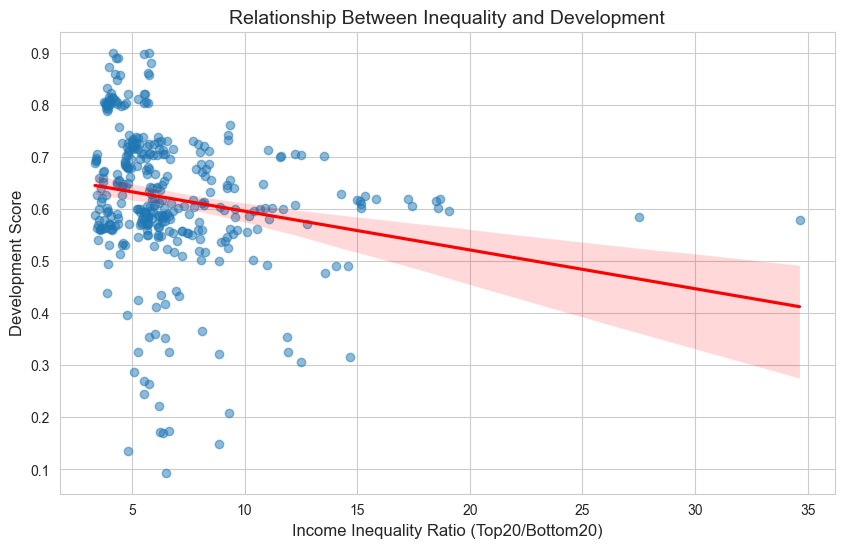

In [15]:
plt.figure()

sns.regplot(
    data=merged_df,
    x="top20_bottom20_ratio",
    y="development_score",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Relationship Between Inequality and Development")
plt.xlabel("Income Inequality Ratio (Top20/Bottom20)")
plt.ylabel("Development Score")

plt.show()

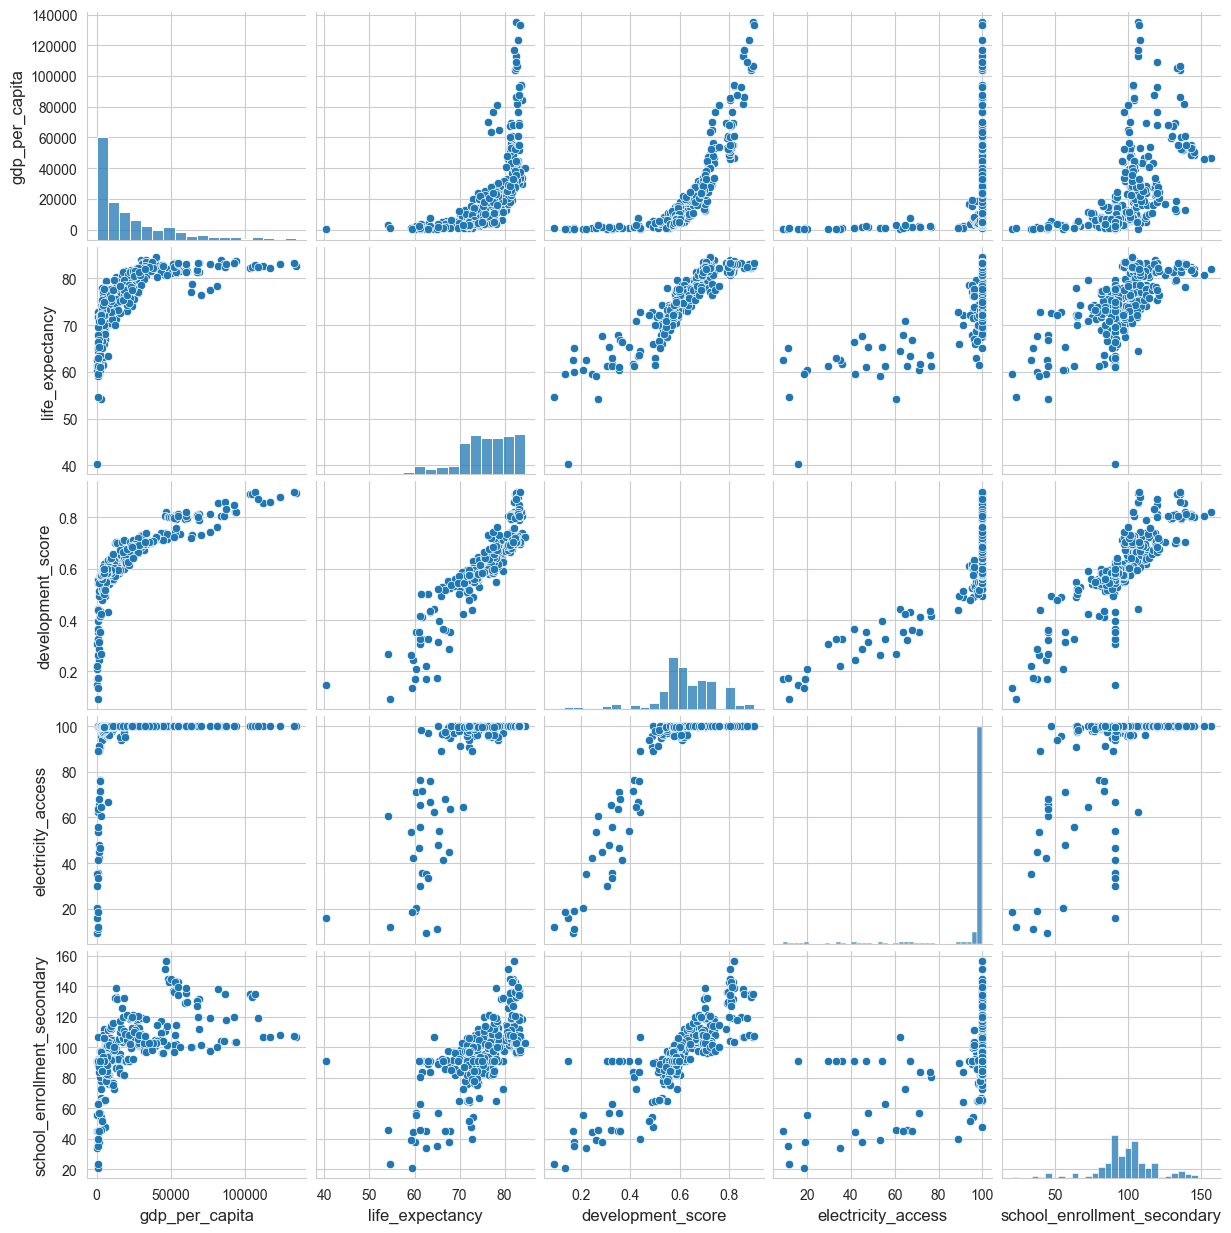

In [17]:
import seaborn as sns

cols = [
    "gdp_per_capita",
    "life_expectancy",
    "development_score",
    "electricity_access",
    "school_enrollment_secondary"
]

# Fixed variable name from 'df' to 'merged_df' to prevent NameError
sns.pairplot(merged_df[cols])


## 9. Geospatial Tracking: Animated Geographic Inequality
**Intent:** An interactive and animated Choropleth density map to project inequality natively onto global geography over time.
**Insight:** Systemic development and structural poverty are inherently regional. Visualizing the mapped densities spatially allows policymakers and developmental scholars to witness "neighborhood gravity effects"—where bordering nations share correlated economic leakages across Sub-Saharan clusters or parts of Latin America over the 2019-2024 time span.

In [18]:
import plotly.express as px

# Aggregate inequality per country-year
map_data = (
    merged_df.groupby(["country_name", "year"], as_index=False)
    ["top20_bottom20_ratio"]
    .mean()
)

# Create animated choropleth map
fig = px.choropleth(
    map_data,
    locations="country_name",
    locationmode="country names",
    color="top20_bottom20_ratio",
    hover_name="country_name",
    hover_data={
        "top20_bottom20_ratio": True,
        "year": True
    },
    animation_frame="year",
    color_continuous_scale="Reds",
    labels={"top20_bottom20_ratio": "Inequality Ratio"},
    title="Global Income Inequality Over Time (Top 20% vs Bottom 20%)"
)

# Improve layout (professional look)
fig.update_layout(
    title_x=0.5,
    geo=dict(showframe=False, showcoastlines=True)
)

fig.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_20380\3079386542.py:11: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


## 10. The Ultimate Divergence: The Paradox of Growth
**Intent:** An authoritative dual-y-axis time series juxtaposing raw per capita wealth accumulation mathematically over the persistent underlying internal Income Ratio.
**Insight:** This resolves our overarching analytical problem statement conclusively. It serves to expose historical periods representing "hollow growth"—the dangerous decoupling instances wherein a state's international financial index (GDP) skyrockets sharply, yet the Top-to-Bottom domestic ratio tracks independently, definitively proving that growth without structural allocation operates blind to alleviation.

In [19]:
import plotly.graph_objects as go

yearly = merged_df.groupby("year").agg({
    "gdp_per_capita":"mean",
    "top20_bottom20_ratio":"mean"
}).reset_index()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=yearly["year"],
        y=yearly["gdp_per_capita"],
        name="GDP per Capita",
        mode="lines+markers",
        yaxis="y1"
    )
)

fig.add_trace(
    go.Scatter(
        x=yearly["year"],
        y=yearly["top20_bottom20_ratio"],
        name="Income Inequality",
        mode="lines+markers",
        yaxis="y2"
    )
)

fig.update_layout(
    title="Economic Growth vs Income Inequality Over Time",
    xaxis_title="Year",
    yaxis=dict(title="GDP per Capita"),
    yaxis2=dict(
        title="Top20 / Bottom20 Ratio",
        overlaying="y",
        side="right"
    ),
    template="simple_white"
)

fig.show()